[INFO] Using device: cuda

 Running K_dim = 2

--- Replicate 1/10 ---
Epoch   5 | Loss=606.833130 | Kurtosis=4.910092
Epoch  10 | Loss=571.542908 | Kurtosis=8.473359
Epoch  15 | Loss=550.749512 | Kurtosis=4.126587
Epoch  20 | Loss=542.938293 | Kurtosis=3.204220
Epoch  25 | Loss=541.721252 | Kurtosis=4.861012
Epoch  30 | Loss=542.620605 | Kurtosis=5.164277
Epoch  35 | Loss=542.821289 | Kurtosis=5.139830
Epoch  40 | Loss=543.568909 | Kurtosis=6.436438
Epoch  45 | Loss=542.400513 | Kurtosis=6.812927
Epoch  50 | Loss=541.293335 | Kurtosis=7.870586
Epoch  55 | Loss=541.338623 | Kurtosis=7.407447
Epoch  60 | Loss=541.580017 | Kurtosis=7.501494
Epoch  65 | Loss=540.943726 | Kurtosis=8.168540
Epoch  70 | Loss=541.187439 | Kurtosis=8.471642
Epoch  75 | Loss=540.704346 | Kurtosis=8.774457
Epoch  80 | Loss=540.364441 | Kurtosis=8.340186
Epoch  85 | Loss=541.456116 | Kurtosis=8.167816
Epoch  90 | Loss=540.862305 | Kurtosis=8.765968
Epoch  95 | Loss=541.509949 | Kurtosis=7.811127
Epoch 100 | Loss=5

ValueError: too many values to unpack (expected 3)

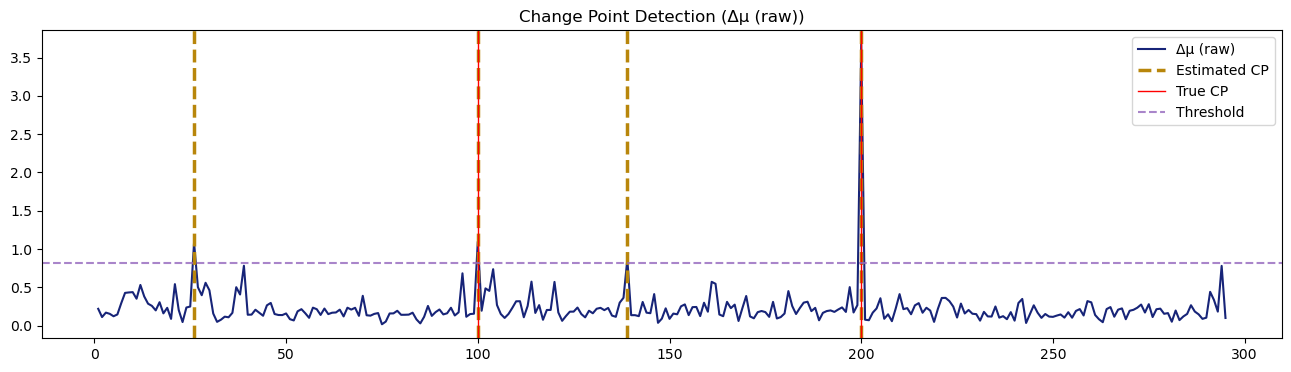

In [ ]:
import torch, random, io, sys, warnings
import os, numpy as np, pandas as pd, pyreadr
from tqdm import tqdm

import sys, os
sys.path.append(os.path.abspath(".."))

from cpd_model import parse_args, learn_one_seq_penalty

warnings.filterwarnings("ignore")

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

# ======================================================
# CONFIG
# ======================================================
REPS = 10
TRUE_CP = [100, 200]
K_LIST = [2, 3, 7] 
TOL = 10

# ======================================================
# BASE ARGS
# ======================================================
base_args = parse_args()
base_args.epoch = 150
base_args.K_dim = 2  
base_args.z_dim = 3  
base_args.decoder_lr = 0.01
base_args.decoder_iteration = 20
base_args.langevin_s = 0.2
base_args.langevin_K = 100
base_args.kappa = 0.8
base_args.penalties = [0.01, 0.05, 0.1, 1]
base_args.nu_iteration = 20
base_args.output_layer = [50, 50]
base_args.scale_delta = False
base_args.signif_level = 0.99
base_args.true_CP_full = TRUE_CP

# ======================================================
# MAIN LOOP
# ======================================================
records = []

GLOBAL_SEED = 1

for K_dim in K_LIST:
    print(f"\n==============================")
    print(f" Running K_dim = {K_dim}")
    print(f"==============================")

    for rep in range(1, REPS + 1):

        print(f"\n--- Replicate {rep}/{REPS} ---")

        # ---------- seed ----------
        SEED = GLOBAL_SEED + rep
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

        # ---------- load data ----------
        Y = pyreadr.read_r(f"../real_data_sim/sim_dat_ult_5_{rep}.RDS")
        X = pyreadr.read_r(f"../real_data_sim/sim_x_ult_5_{rep}.RDS")

        Y_df = np.array(list(Y.values())[0])
        X_df = np.array(list(X.values())[0])

        # expand X
        X_rep = np.repeat(X_df[:, np.newaxis, :], 100, axis=1)
        Y = Y_df[:, :, 0:3]
        X = X_rep

        # ---------- args ----------
        args = parse_args()
        args.__dict__.update(base_args.__dict__)

        args.K_dim = K_dim 
        args.x_dim = X.shape[2]
        args.y_dim = Y.shape[2]
        args.num_time = X.shape[0]
        args.num_samples = X.shape[1]

        # ---------- tensor ----------
        x_input = torch.tensor(X, dtype=torch.float32).to(device)
        y_input = torch.tensor(Y, dtype=torch.float32).to(device)

        # ---------- split ----------
        odd_idx = range(1, args.num_time, 2)
        even_idx = range(0, args.num_time, 2)

        x_train = x_input[odd_idx].reshape(-1, args.x_dim)
        x_test  = x_input[even_idx].reshape(-1, args.x_dim)
        y_train = y_input[odd_idx].reshape(-1, args.y_dim)
        y_test  = y_input[even_idx].reshape(-1, args.y_dim)

        # ======================================================
        # penalty selection
        # ======================================================
        results_half = []

        for penalty in args.penalties:
            _stdout = sys.stdout
            # sys.stdout = io.StringIO()
            try:
                loss, pen = learn_one_seq_penalty(
                    args, x_train, y_train, x_test, y_test,
                    penalty=penalty, half=True
                )
            finally:
                sys.stdout = _stdout

            results_half.append([loss, pen])

        results_half = np.array(results_half)
        best_idx = np.argmin(results_half[:, 0])
        best_penalty = args.penalties[best_idx]

        print(f"[INFO] Best penalty = {best_penalty}")

        # ======================================================
        # full training
        # ======================================================
        _stdout = sys.stdout
        sys.stdout = io.StringIO()
        try:
            out = learn_one_seq_penalty(
                args,
                x_input.reshape(-1, args.x_dim),
                y_input.reshape(-1, args.y_dim),
                x_input.reshape(-1, args.x_dim),
                y_input.reshape(-1, args.y_dim),
                penalty=best_penalty,
                half=False
            )
            result = out[0]
        finally:
            sys.stdout = _stdout

        torch.cuda.empty_cache()

        # ======================================================
        # evaluation
        # ======================================================
        est_cp = np.array(result[5], dtype=int) if len(result[5]) > 0 else np.array([])
        true_cp = np.array(TRUE_CP)

        if len(est_cp) == 0:
            cover_rate = 0
            avg_dist = np.nan
            FP = 0
            FN = len(true_cp)
        else:
            dist_mat = np.abs(est_cp[:, None] - true_cp[None, :])
            min_dist_true = dist_mat.min(axis=0)
            min_dist_est  = dist_mat.min(axis=1)

            cover_rate = np.mean(min_dist_true <= TOL)
            avg_dist   = np.mean(min_dist_true)
            FP = np.sum(min_dist_est > TOL)
            FN = np.sum(min_dist_true > TOL)

        # ======================================================
        # record
        # ======================================================
        records.append({
            "K_dim": K_dim,
            "rep": rep,
            "best_penalty": best_penalty,
            "num_detected": len(est_cp),

            # core output
            "est_CP": str(list(est_cp)),
            "true_CP": str(TRUE_CP),

            # optional debug
            "CE": result[0],
        })

# ======================================================
# SAVE
# ======================================================
df = pd.DataFrame(records)
df.to_csv("cpd_Kdim_experiment.csv", index=False)
